<a href="https://colab.research.google.com/github/praksb2428-maker/Deep.practice/blob/main/d_l_Project_md.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 프로젝트 제안서

### 개요

프로젝트 목표: 서울의 6~8월 평균/최고 온도 및 폭염 확률 예측

알고리즘 상세: CNN-LSTM: CNN으로 기온의 급변을 포착하고, LSTM으로 16년치 장기 패턴을 학습하는 하이브리드 전략을 사용합니다. 특히 국소 변동성이 큰 여름 데이터 분석에 핵심적입니다.

GRU: CNN-LSTM보다 연산 속도가 빠르기 때문에, 결과를 빠르게 확인하고 모델의 성능 기준점(Baseline)을 잡기 위해 사용합니다.

라이브러리 역할:

- Numpy: 배열 연산 및 결측치 보간

- Pandas: 데이터 로드 및 학습 관리

- Scikit-learn: 전처리, 평가지표 산출 및 모델 비교

- Matplotlib/Seaborn: EDA 및 결과 검증

### 배경
- 6~8월은 온열 질환 위험성이 높은 시기이지만, 현재는 국가에서 발송하는 재난 문자에 의존하는 수동적인 대응에 머물러 있습니다. 단순히 외출을 자제하라는 문자 대신 개인이 직접 데이터를 확인하고 활동의 효율성을 스스로 판단할 수 있는 기준이 필요하다 생각했습니다. 16년치 기상 데이터를 분석하여 2026년 폭염 확률을 예측함으로써 사용자가 당일 활동의 효율성을 높이는 것이 목적입니다.

### 목표
- 과거 2010-2025년 6월-8월 기상청 온도, 강수량 데이터를 모델에 학습시켜서 여름의 온도를 예측하여 평균온도, 최고온도, 폭염일 확률을 출력하는 모델

### 전처리 방법 수정
1. 단순하게 df.dropna()로 해당 행을 제거, 또는 평균 / 선형 보간 등으로 대체

2. 정규화/스케일링 방식을 바꾸는 방법

3. MinMaxScaler 대신 Z‑score (StandardScaler) : 평균을 0, 분산을 1로 만들어서 이상치에 영향을 덜 받게 합니다.

4. RobustScaler : 중앙값과 IQR을 기준으로 스케일링해서, 폭우·폭염 같은 극단치에 훨씬 덜 민감합니다.

### 기존 프로젝트 개선점, 변경점
변경점
- kaggle에 있는 "Daily Climate(time series LSTM and CNN" 이 프로젝트는 4계절을 학습하는 구조로 되어있지만 6~8월 여름을 특정 학습하여 여름특화 학습하는 구조


2. RMSE말고도 성능을 평가하는 알고리즘 MAE, R², MAPE 등을 함께 사용하여 평가
- MAE (Mean Absolute Error), °C온도 : 예측값과 실제값의 차이를 절댓값으로 해서 평균낸 값, 직관적, 이상치 덜 민감
- R²(결정계수), 0~1 : 모델이 데이터의 변동성을 몇 % 설명하는지, 모델 신뢰도가 1에 가까울수록 좋음
- MAPE (Mean Absolute Percentage Error), %의미 : 오차를 실제값 대비 백분율로 표현, 스케일 독립적, 수치가 0근처일 때 주의


###  데이터셋 크기
- 행 수 (Total Rows): 1,472
- 열 수 (Total Columns): 4

### 데이터 기간
 - 2010-2525년 6-8월

 ### 데이터
| 날짜(YYYY-MM-DD) | Average Temperature(℃)	 | Maximum(℃) | Precipitation(mm) |
| :--- | :--- | :--- | :--- |
| 2010-06-01 | 19.1 | 26.2 | 0.0 |
| 2010-06-02 | 21.0 | 26.6 | 0.0 |
| 2010-06-03 | 21.1 | 26.5 | 0.0 |
| 2010-06-04 | 22.3 | 27.9 | 0.0 |
| 2010-06-05 | 23.3 | 28.4 | 0.0 |

### 라벨링 방식
평균온도(℃) :

  30(℃) 이상 : 2

  25(℃)~30(℃) 중간 : 1

  25(℃) 미만 : 0

최고온도(℃) :

  35(℃) 이상 : 2

  29(℃) ~ 35(℃) 중간 : 1

  29 미만은 0

강수량(mm) :

  40mm 이상 : 2

  20mm 이상은 : 1

  20mm 미만은 : 0

### 성능평가
MAE, RMSE의 차이가 적고 MAPE가 10% 이내로 정착한 것을 확인. R²에서는 평균기온은 양호하게 되었지만 최고기온 에서는 준수하게 출력된 것을 확인하였다.

- 1. 일 평균기온 (Average Temperature) 예측 결과
   - MAE  (평균 절대 오차)   : 1.4046 ℃
   - RMSE (평균 제곱근 오차) : 1.8035 ℃
   - R²   (결정계수 / 설명력) : 0.6173
   - MAPE (평균 백분율 오차) : 5.4914 %

- 2. 일 최고기온 (Maximum Temperature) 예측 결과
   - MAE  (평균 절대 오차)   : 2.1115 ℃
   - RMSE (평균 제곱근 오차) : 2.6580 ℃
   - R²   (결정계수 / 설명력) : 0.3961
   - MAPE (평균 백분율 오차) : 7.2828 %


### 각 연도별 온도 시각화
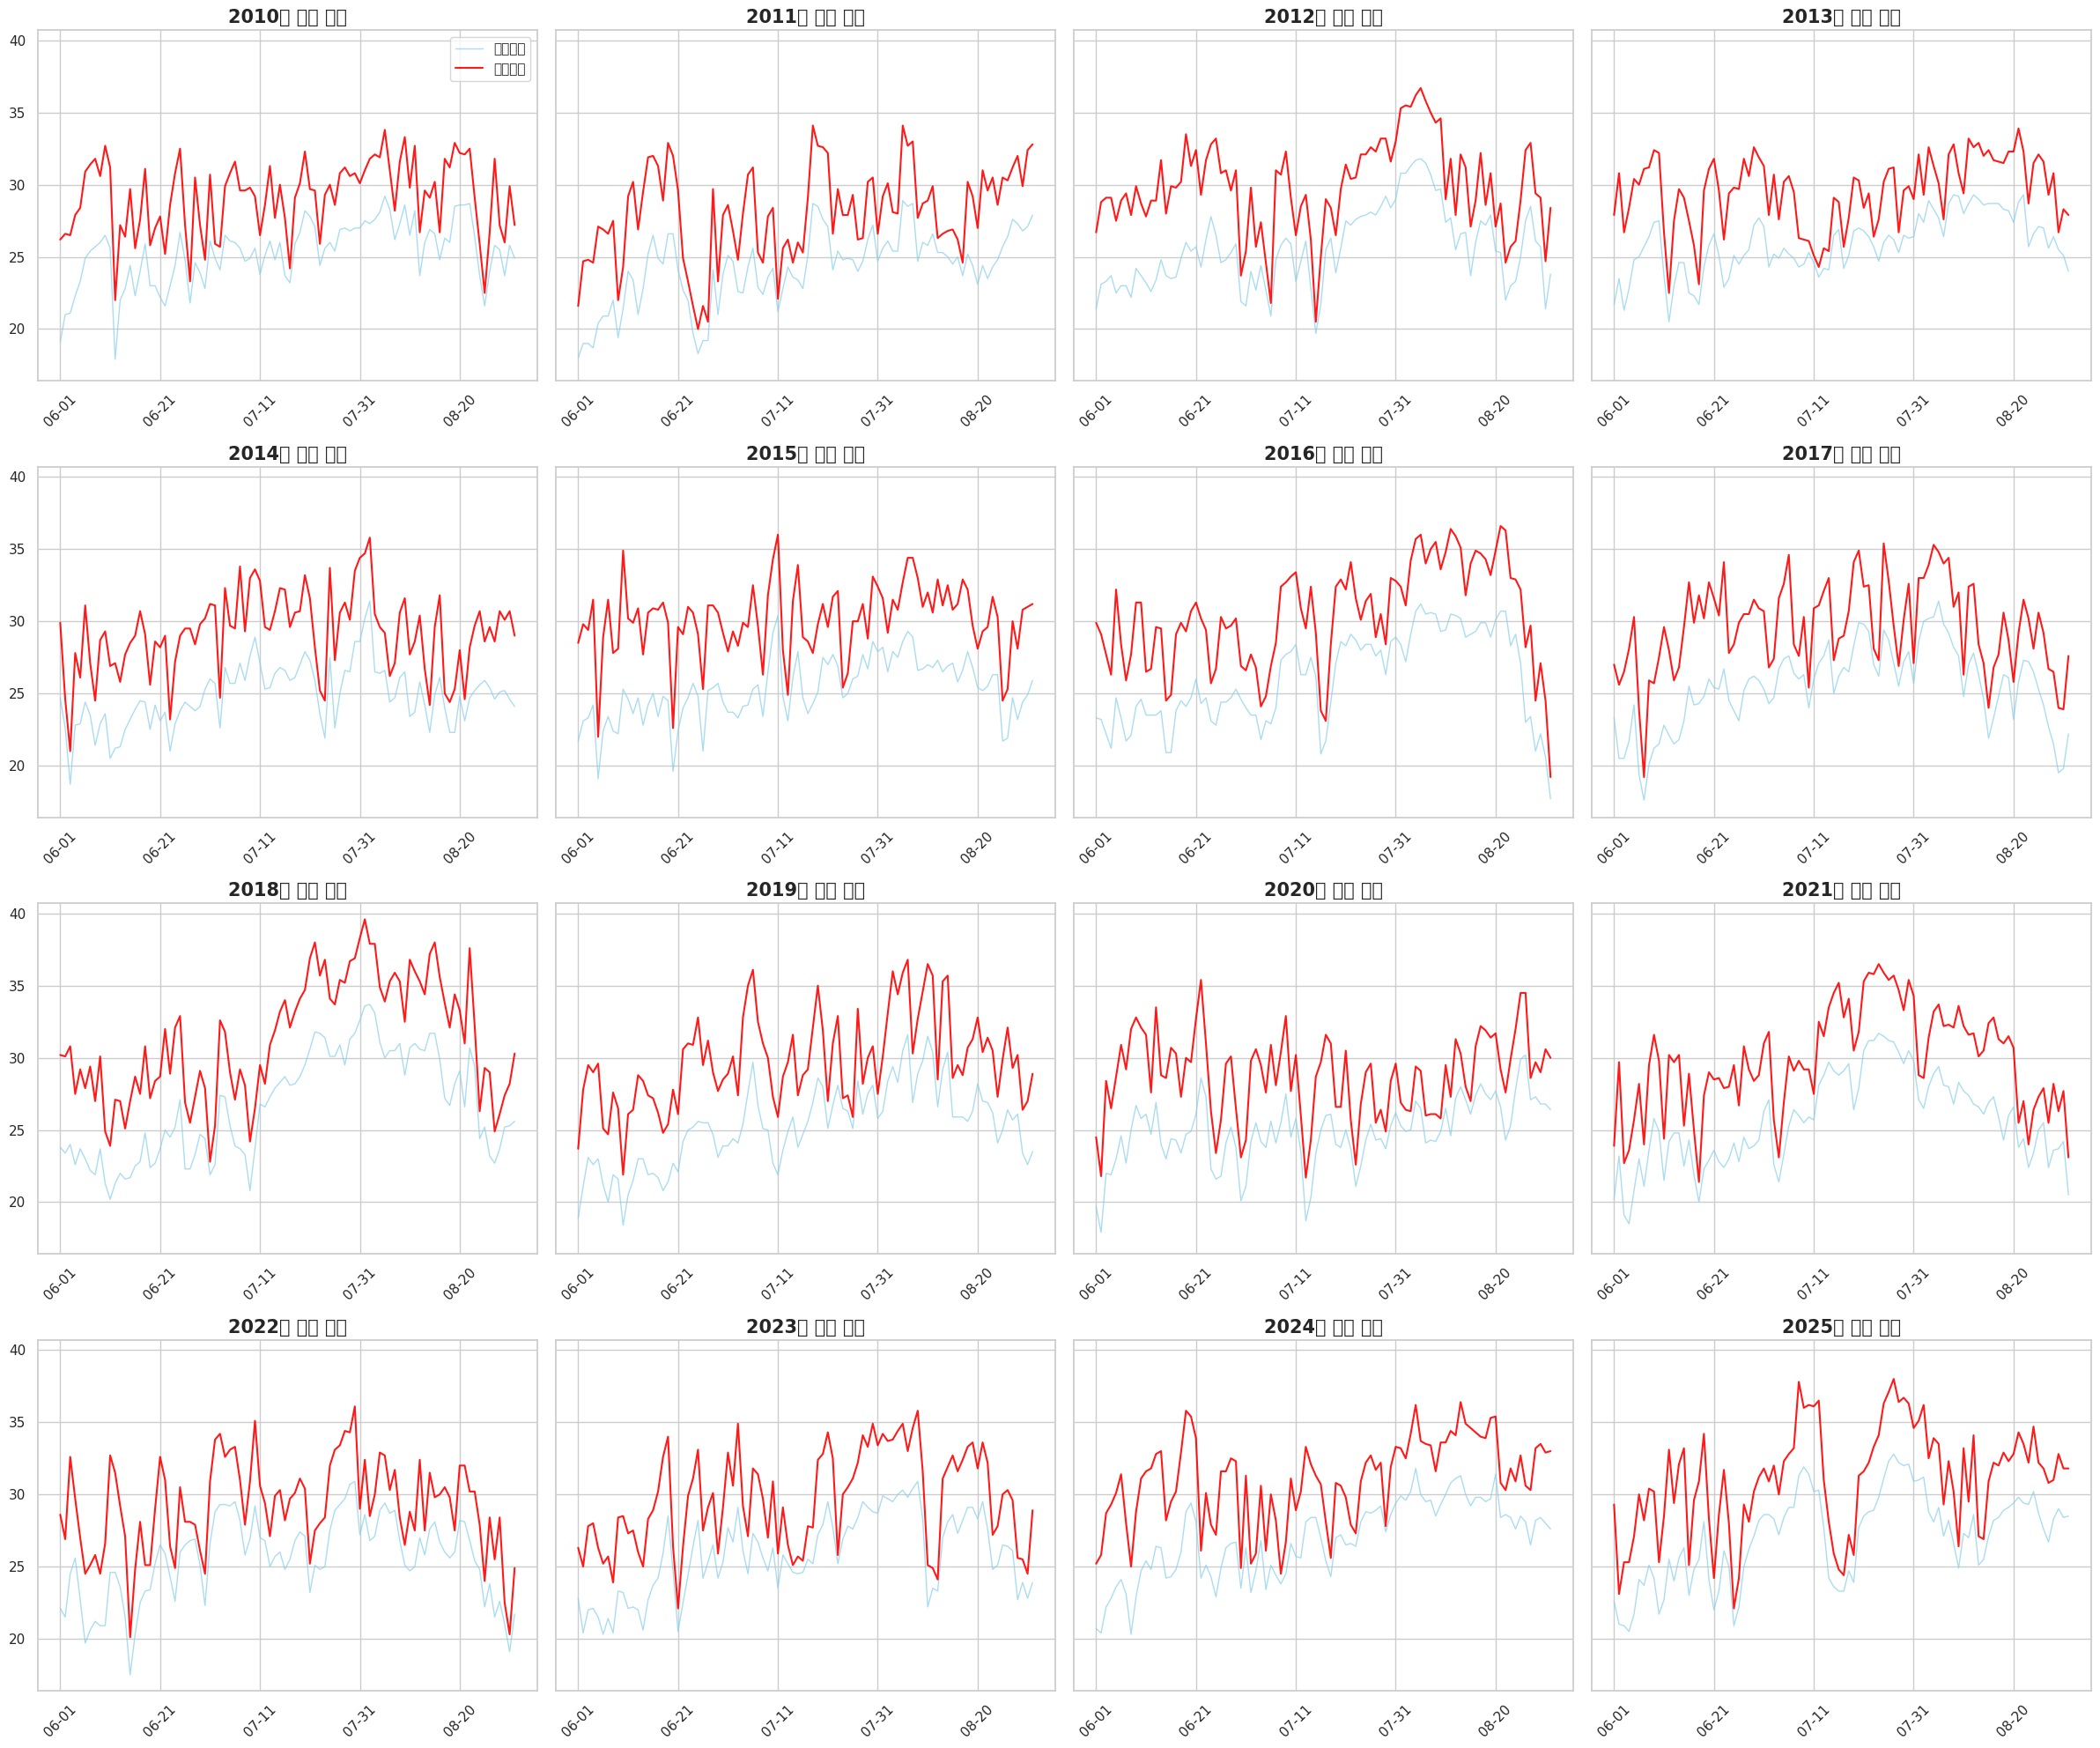

### 적용할 가중치
1. 가중치 부여체감 온도 보정$+2.0^\circ\text{C}$ 가산
  - 강수량의 라벨링이 0 이면 온도와 관련이 없게 설정
  - 강수량의 라벨링이 1 이상일 때 각 온도에 2도를 추가
가중치 부여체감 온도 보정$+2.0^\circ\text{C}$ 가산

  가중치 부여 후
- 평균온도(℃) :
  
  30(℃) > 32(℃)
  
  25(℃)-30(℃) > 27(℃)-32(℃)

  25(℃) > 27(℃)

- 최고온도(℃) :

  35(℃) > 37(℃)

  29(℃)-35(℃) > 31(℃)-37(℃)

  29(℃) > 31(℃)

2.최신 데이터일수록 가중치를 높게 설정

2019년 이전 데이터 (2010년 ~ 2019년): 1.0 (기본 베이스라인 가중치)

2020년 데이터: 1.5

2021년 데이터: 2.0

2022년 데이터: 2.5

2023년 데이터: 3.0

2024년 데이터: 3.5

### 기대효과
이 프로젝트는 "재난 문자를 기다리는 사람"을 "데이터를 보고 하루를 설계하는 사람"으로 바꾸는 기술적 전환점이 될 것입니다

### 향후 일정
2026.04.27

기상청 데이터포털 접속 → 서울 2010-2025년 5-8월 CSV 다운로드
Pandas로 데이터 로드/탐색 (결측치, 통계)
여름 6-8월 데이터만 추출 + 기본 시각화 (Matplotlib)

2026.04.30

- TimeSeriesSplit 검증셋 구성
- CNN-LSTM 입력 배열 생성 (window=14)

2026.05.04

- CNN-GRU 모델 구현
- MAE/R² 4지표 평가
- 결과 시각화

2026.05.11

- CNN-LSTM 모델 구현
- CNN-GRU vs CNN-LSTM 성능 비교

2026.05.18

- 0.7*LSTM + 0.3*GRU 앙상블 테스트
- EarlyStopping, Dropout 과적합 방지
 -하이퍼파라미터 튜닝 (window, units)

2026.05.26

- 성능표, 그래프 완성 (실제vs예측)
- README.md
- 2026년 6~8월 예측 테스트

2026.05.29

- 최종 점검